In [2]:
import sys   # DynaMix's internal src fallback

from src_v1.utils import get_all_paths
from src_v1.utils import load_activation_data

from dynamix.model.forecaster import DynaMixForecaster
from dynamix.utilities.utilities import load_hf_model
from dynamix.utilities.plotting_eval import plot_TS_forecast

In [3]:
import numpy as np
import pandas as pd

volta = np.load("/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/AFOR/bfa/155Vs/10Hz/2025_07_07__AFOR__DA_5HT_NE__155Vs_10Hz__BFA_INM001_99bW06R09/DA_5HT_NE/voltammograms.npy")

In [16]:
labels = np.load("/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/AFOR/bfa/155Vs/10Hz/2025_07_07__AFOR__DA_5HT_NE__155Vs_10Hz__BFA_INM001_99bW06R09/DA_5HT_NE/labels.npy")

In [17]:
labels.shape

(15, 600)

In [18]:
labels2 = np.load("/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/ALCIS_155_macroREF/alc1/155Vs/10Hz/2025_09_30__RIGINM__DA__155Vs_10Hz__ALC1_INM001_01bW04R01M/DA/labels.npy")

In [19]:
labels2.shape

(35, 600)

In [23]:
labels2 = labels2.reshape(35,150,4)[:,0,:]
labels2.shape

(35, 4)

In [20]:
labels = labels.reshape(15*150,4)
labels.shape

(2250, 4)

In [21]:
labels[0,:]

array([0. , 0. , 0. , 7.4], dtype=float32)

In [5]:
volta.shape

(15, 1000, 150)

In [8]:
volta_mean = volta.mean(axis=2,keepdims=True)
volta_mean.shape

(15, 1000, 1)

In [11]:
volta_T = volta.transpose(0,2,1).reshape(-1,1000,1)
volta_T.shape

(2250, 1000, 1)

In [2]:

weights_paths = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl"
voltammograms_path = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/AFOR/bfa/155Vs/10Hz/2025_07_07__AFOR__DA_5HT_NE__155Vs_10Hz__BFA_INM001_99bW06R09/DA_5HT_NE/voltammograms.npy"
labels_path = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/AFOR/bfa/155Vs/10Hz/2025_07_07__AFOR__DA_5HT_NE__155Vs_10Hz__BFA_INM001_99bW06R09/DA_5HT_NE/labels.npy"

train, val, test, y_mean, y_std, mono_dom_l = load_activation_data(weights_paths, batch_size=32, collapsed=True,volta=True)


Getting pairs collapsed.
First activation shape(35, 1000, 1)
First label shape(35, 4)
Expert activation set shape: (1068, 1000, 1)
Labels shape: (1068, 4)
First label row (all 4 cols): [0.  0.  0.  7.4]
y_mean: [497.5521  429.1797  415.22134]  y_std: [735.66486 707.9236  687.7408 ]


In [3]:
# Hook into the gating network output
import torch 

gating_outputs = []
device = torch.device("mps")
def hook_fn(module, input, output):
    gating_outputs.append(output.detach().cpu())
    
model = load_hf_model("dynamix-6d-alrnn-v1.0")
model.eval()
model.to(device)
hook = model.gating_network.mlp_layer2.register_forward_hook(hook_fn)
forecaster = DynaMixForecaster(model)

for name, params in model.named_parameters():
    print(name, params)


import inspect
print(inspect.signature(model.forward))



B Parameter containing:
tensor([[ 1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00, -2.3858e-02, -4.7947e-02,  1.6942e-01,  1.1427e-01],
        [ 0.0000e+00,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  2.0215e-01,  4.5089e-02,  1.3541e-03,  1.8340e+00],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00, -1.4889e-01, -1.8194e-01, -8.0520e-01,  5.4069e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  7.1277e-02, -9.8463e-02,  6.7404e-02, -1.0604e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00, -4.4109e-02,  7.0751e-02, -5.0871e-02, -1.6043e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          1.0000e+00,  1.1812e-02,  1.8853e-02,  5.5128e-01, -1.9771e-01]],
       device='mps:0', requires_grad=True)
experts.0.A Parameter containing:
tens

In [ ]:
exp_params = [i for i in model.experts.parameters()]
print(int(len(exp_params)/3))

80.0


In [6]:
# Run inference on your data
with torch.no_grad():
    for X_batch, _, _ in train:
        X_batch = X_batch.to(device)
        for i in range(X_batch.shape[0]):
            context = X_batch[i]
            _ = forecaster.forecast(
                context=context,
                horizon=100
            )

hook.remove()
gating_features = torch.cat(gating_outputs, dim=0).numpy()  # (N, 80)

In [7]:
gating_features.shape

(76800, 80)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

def visualize_embeddings(X, y,title_suffix="Train Set"):
    
    print("Running PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    print("Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X)

    print("Running UMAP...")
    reducer = umap.UMAP(n_neighbors=5,min_dist=0.01,n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)

    # --- Plot ---
    class_names = {0: "DA", 1: "5HT", 2: "NE", 3: "Tie/EQ"}
    colors      = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71", 3: "#9b59b6"}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (X_emb, name) in zip(axes, [
        (X_pca,  "PCA"),
        (X_tsne, "t-SNE"),
        (X_umap, "UMAP"),
    ]):
        for cls in sorted(np.unique(y)):
            mask = y == cls
            ax.scatter(
                X_emb[mask, 0], X_emb[mask, 1],
                c=colors[int(cls)],
                label=class_names[int(cls)],
                alpha=0.6, s=15, edgecolors='none'
            )
        ax.set_title(name)
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.legend(markerscale=2)

    plt.tight_layout()
    plt.show()

In [26]:
gating_outputs = np.array(gating_outputs).reshape(-1,80)
gating_outputs.shape
y_all = [] 
for _, y_batch, _  in train:
        y_all.append(y_batch.numpy())

y_all = np.concatenate(y_all,axis=0)

N = len(y_all)
gating_outputs = gating_outputs.reshape(N, -1, 80)
print(f"gating_outputs shape: {gating_outputs.shape}")
print(f"y_all shape: {y_all.shape}")

gating_outputs shape: (768, 100, 80)
y_all shape: (768,)


Running PCA...
Running t-SNE...
Running UMAP...


/opt/anaconda3/envs/dynamix/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


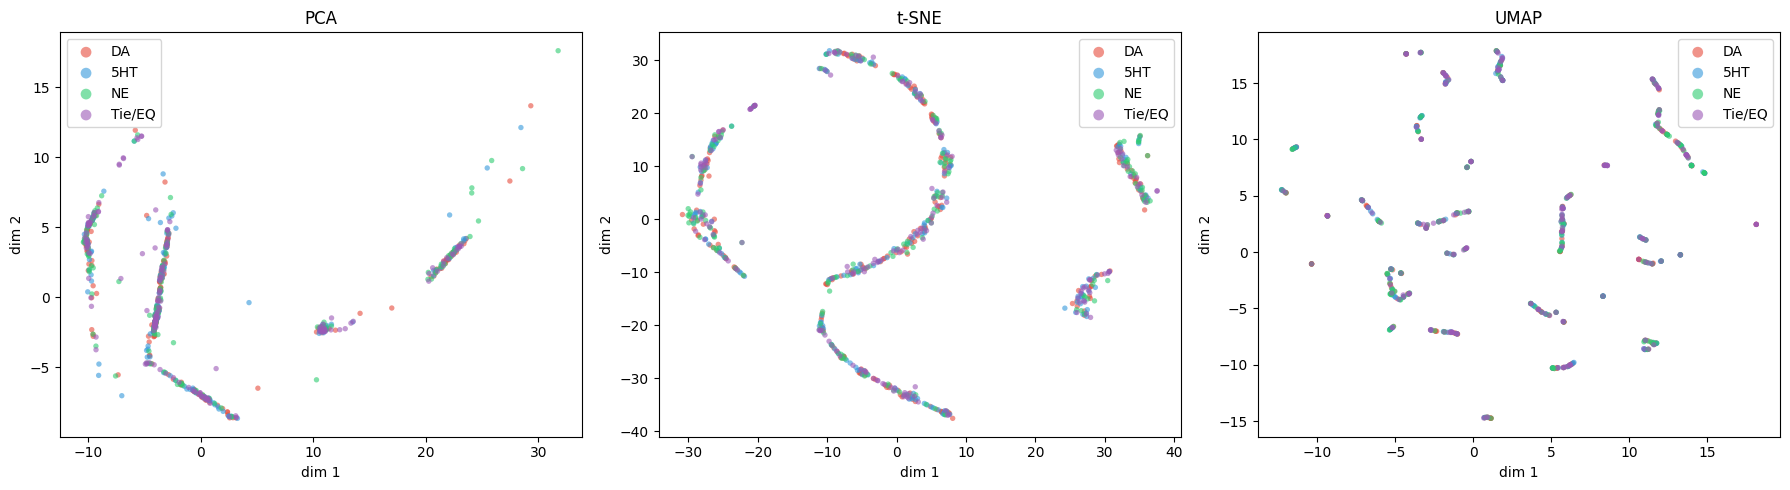

In [29]:
visualize_embeddings(gating_outputs.max(axis=1), y=y_all)

In [30]:
gating_outs_test = []

def hook_fn_t(module, input, output):
    gating_outs_test.append(output.detach().cpu())

hook = model.gating_network.mlp_layer2.register_forward_hook(hook_fn_t)

with torch.no_grad():
    for X_batch, _, _ in test:
        X_batch = X_batch.to(device)
        for i in range(X_batch.shape[0]):
            context = X_batch[i]
            _ = forecaster.forecast(
                context=context,
                horizon=100
            )

hook.remove()


In [31]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(gating_outputs.mean(axis=1), y_all)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [35]:
y_all_test = [] 
for _, y_batch, _  in test:
        y_all_test.append(y_batch.numpy())

y_all_test = np.concatenate(y_all_test,axis=0)

N = len(y_all_test)
gating_outs_test = np.array(gating_outs_test).reshape(N, -1, 80)
print(f"gating_outputs shape: {gating_outs_test.shape}")
print(f"y_all shape: {y_all_test.shape}")

gating_outputs shape: (214, 100, 80)
y_all shape: (214,)


In [36]:
y_pred = svm.predict(gating_outs_test.mean(axis=1))

from sklearn.metrics import accuracy_score

print(accuracy_score(y_true=y_all_test,y_pred=y_pred))

0.2803738317757009
